# 04 — Multiclass Decoding (all four conditions)

**Purpose:** Move from two-class to **four-class** decoding. The decoder must now
assign each trial to one of `pos_val`, `neg_val`, `pos_aro`, `neg_aro`. This is
harder than any binary problem, chance drops to **25%**, and the most useful
output is no longer a single accuracy but a **confusion matrix** that shows
*which* conditions get mixed up.

> Reference: Nilearn's decoding tutorials include multiclass examples; the
> `Decoder` object handles multiclass automatically (one-vs-rest under the hood),
> so most of your binary pipeline carries straight over.

---

## Notebook overview

1. Load `sub-097_decoder_4class.csv` (all 64 trials, four labels).
2. Build `imgs`, `y`, `groups`.
3. Set up a per-classifier **run folder** for this decoder's outputs.
4. Reuse the decoder pipeline — it goes multiclass with no special handling.
5. Score against chance = 25%.
6. Build and read a **confusion matrix** to interpret the decoder's mistakes.

## What you are learning

- What **multiclass classification** is and why it is harder than binary.
- Why chance = **1 / n_classes** = 25% here.
- How to build, plot, and *read* a **confusion matrix**.
- How to turn "the decoder's mistakes" into a scientific observation.
- How to organise outputs into a timestamped run folder (provenance).

## Why this matters scientifically

Overall 4-class accuracy is a blunt summary. The *pattern of confusions* is the
interesting part: if the decoder reliably tells valence-conditions from
arousal-conditions but muddles positive vs negative *within* a dimension, that
tells you the dimension is more strongly represented than the sign. A confusion
matrix turns a single number into a structured hypothesis about representational
geometry.

---
## Section 1 — From Binary to Multiclass

A binary SVM draws one boundary. With four classes, scikit-learn (and Nilearn's
`Decoder`) typically trains **one-vs-rest**: a separate "is it this class or
not?" SVM per class, then predicts whichever is most confident. You do not have
to code this — passing four distinct labels in `y` is enough.

Why is it harder?

- More ways to be wrong: each trial can be misassigned to any of three other
  classes, not just one.
- The data is spread thinner: 16 trials per class, and within each CV fold the
  training set is smaller still.
- **Chance = 1 / number_of_classes = 1 / 4 = 25%.** A decoder scoring 30% is
  doing *something*, even though 30% sounds low — context (the 25% bar) is
  everything.

---
## Section 2 — Load the 4-Class Table and Build Inputs

The file you saved from notebook 00 is `sub-097_decoder_4class.csv`.

**TODO:**
- [ ] Read `sub-097_decoder_4class.csv` into `table`.
- [ ] Confirm `table["label"].value_counts()` shows 16 for each of the four classes.
- [ ] Build `imgs`, `y`, `groups`; assert equal lengths.

In [12]:
from pathlib import Path
import pandas as pd
import numpy as np

subject = "sub-097"
project_dir  = Path(r"C:\ManzaRotation")
decoding_dir = project_dir / "Analysis" / "outputs" / subject / "decoding"
tables_dir   = decoding_dir / "tables"

# TODO: read tables_dir / f"{subject}_decoder_4class.csv" into `table`
table = pd.read_csv(tables_dir / f"{subject}_decoder_4class.csv")

# TODO: check 16 per class with table["label"].value_counts()
table["label"].value_counts()
# TODO: build imgs, y, groups from the path / label / groups columns (.tolist())
imgs = table["path"].tolist()
y = table["label"].tolist()
groups = table["groups"].tolist()

# TODO: assert len(imgs) == len(y) == len(groups)
assert(len(imgs)==len(y)==len(groups))

---
## Section 3 — Set Up a Run Folder for This Classifier

Before fitting, create a place to put this decoder's outputs — including the
confusion-matrix figure you'll build in Section 6. As with the other decoders,
give **each decoding question its own top-level folder** and **each run its own
timestamped subfolder**:

```
decoding/
  fourclass_decoding/                 <- one folder per decoding question
    runs/
      2026-06-25_1530_fourclass_svc/  <- one folder per run
        figures/      # confusion matrix, weight maps
        scores/       # the results CSV
        params.json   # exactly which settings produced this run
```

The pattern is the same one notebooks 01 and 02 use in finished form — here it is
your job to fill it in:

```python
from datetime import datetime
import json

timestamp = datetime.now().strftime("%Y-%m-%d_%H%M")
run_dir   = decoder_dir / "runs" / f"{timestamp}_{analysis_name}"
figures_dir = run_dir / "figures"
results_dir = run_dir / "scores"
figures_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)
```

**TODO (fill in the cell below):**
- [ ] Define `decoder_dir = decoding_dir / "fourclass_decoding"`.
- [ ] Set `analysis_name = "fourclass_svc"`.
- [ ] Build `timestamp`, `run_dir`, `figures_dir`, `results_dir` and create them.
- [ ] Later: save the confusion-matrix PNG into `figures_dir`, the scores into
      `results_dir`, and a `params.json` into `run_dir`.

In [13]:
from datetime import datetime
import json
analysis_name = "fourclass_svc"
# A "run folder" keeps everything from one fitting run together — figures,
# scores, and a params.json — under a timestamped subfolder. This mirrors the
# runs/ convention from the beta-series notebooks and the finished valence /
# arousal decoders (notebooks 01 and 02). One TOP folder per decoding question;
# one timestamped subfolder per time you run it.

# TODO: name a folder for THIS classifier (the 4-class question)
decoder_dir = decoding_dir / "fourclass_decoding"
decoder_dir.mkdir(exist_ok=True)
runs_dir = decoder_dir / "runs" 
runs_dir.mkdir(exist_ok=True)
# TODO: give this analysis a short name string, e.g. "fourclass_svc"

timestamp =datetime.now().strftime("%Y-%m-%d_%H%M")

run_number = len(list(runs_dir.glob("run_*")))+1
run_dir = runs_dir / f"{run_number:03d}_{timestamp}_{analysis_name}"


figures_dir = run_dir / "figures"   
results_dir = run_dir / "scores"
# TODO: create BOTH with .mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)
# print(run_dir)   # uncomment once defined, to confirm where outputs will land

---
## Section 4 — Reuse the Pipeline (Now Multiclass)

The same `Decoder` configuration works. Two small notes:

- `scoring="accuracy"` still makes sense, but with four classes you may also want
  per-class scores — `decoder.cv_scores_` is keyed by class, so you get those for
  free.
- Keep `LeaveOneGroupOut` so each fold still tests on a held-out run.

**TODO:**
- [ ] Point `mask_path` at the brain mask.
- [ ] Build `cv = LeaveOneGroupOut()` and the same-style `Decoder`.
- [ ] `decoder.fit(imgs, y, groups=groups)`.
- [ ] Print `decoder.cv_scores_` (per class) and the overall mean accuracy vs 25%.
- [ ] Save the per-class scores into `results_dir` and a `params.json` into `run_dir`.

In [ ]:
from nilearn.decoding import Decoder
from sklearn.model_selection import LeaveOneGroupOut

# func_deriv_dir = project_dir / "Derivatives" / subject / "func"
# TODO: mask_path = ...
# TODO: cv = LeaveOneGroupOut()
# TODO: decoder = Decoder(estimator="svc", mask=mask_path, standardize="zscore_sample",
#                         screening_percentile=..., scoring="accuracy", cv=cv)
# TODO: decoder.fit(imgs, y, groups=groups)
# TODO: print per-class cv_scores_ and the mean vs 25% chance

In [15]:
from datetime import datetime
import json
import pandas as pd
import numpy as np
from nilearn import plotting
from nilearn.decoding import Decoder
from sklearn.model_selection import LeaveOneGroupOut



func_deriv_dir = project_dir / "Derivatives" / subject / "func"
# TODO: mask_path = ...
mask_path = func_deriv_dir / f"{subject}_task-modulate1_space-MNI152NLin2009cAsym_res-2_desc-brain_mask.nii.gz"
cv = LeaveOneGroupOut()

decoders = {}
results= []
for screening_percentile in [1, 2, 5, 10, 25, 50]:
    # Build the decoder for this screening percentile
    decoder = Decoder(
        estimator="svc",
        mask=mask_path,
        standardize="zscore_sample",
        screening_percentile=screening_percentile,
        scoring="accuracy",
        cv=cv,
    )

    # Fit the decoder using images, labels, and run/group labels
    decoder.fit(imgs, y, groups=groups)
    decoders[screening_percentile] = decoder
    # Loop over the cross-validation scores saved inside the fitted decoder
    for label, scores in decoder.cv_scores_.items():
        mean_score = np.mean(scores)
        one_result = {
            "subject": subject,
            "screening_percentile": screening_percentile,
            "label": label,
            "fold_scores": scores,
            "mean_score": mean_score
        }
        results.append(one_result)
    for label, images in decoder.coef_img_.items():
        plotting.plot_stat_map(
            images,
            title=f"SVM weight map for {label}",
            display_mode="ortho",
            cut_coords=(0, 0, 0),
            cmap="RdBu_r",
            colorbar=True,
            threshold=0,
            output_file=figures_dir / f"{subject}_{screening_percentile}_svm_weight_map_{label}.png"
        )
results_df = pd.DataFrame(results)
results_df.to_csv(
    results_dir / f"{subject=}_{analysis_name}.csv",
    index=False
)

# Save run settings so this run is reproducible
params = {
    "subject": subject,
    "analysis_name": analysis_name,
    "estimator": "svc",
    "standardize": "zscore_sample",
    "screening_percentiles": [1, 2, 5, 10, 25, 50],
    "scoring": "accuracy",
    "cv": "LeaveOneGroupOut",
    "mask_path": str(mask_path),
}
with open(run_dir / "params.json", "w") as f:
    json.dump(params, f, indent=4)

results_df


C:\Users\jwhit\AppData\Local\Temp\ipykernel_20652\624729178.py:30: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  decoder.fit(imgs, y, groups=groups)
C:\Users\jwhit\AppData\Local\Temp\ipykernel_20652\624729178.py:30: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  decoder.fit(imgs, y, groups=groups)
C:\Users\jwhit\AppData\Local\Temp\ipykernel_20652\624729178.py:30: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  decoder.fit(imgs, y, groups=groups)
C:\Users\jwhit\AppData\Local\Temp\ipykernel_20652\624729178.py:30: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  

,subject,screening_percentile,label,fold_scores,mean_score
0,sub-097,1,neg_aro,"[0.375, 0.46875]",0.421875
1,sub-097,1,neg_val,"[0.40625, 0.3125]",0.359375
2,sub-097,1,pos_aro,"[0.21875, 0.375]",0.296875
3,sub-097,1,pos_val,"[0.46875, 0.5625]",0.515625
4,sub-097,2,neg_aro,"[0.375, 0.5]",0.437500
5,sub-097,2,neg_val,"[0.40625, 0.28125]",0.343750
6,sub-097,2,pos_aro,"[0.21875, 0.34375]",0.281250
7,sub-097,2,pos_val,"[0.4375, 0.53125]",0.484375
8,sub-097,5,neg_aro,"[0.375, 0.5]",0.437500
9,sub-097,5,neg_val,"[0.34375, 0.3125]",0.328125


---
## Section 5 — Get Cross-Validated Predictions for a Confusion Matrix

A confusion matrix compares **true** labels to **predicted** labels. You need a
prediction for every trial, made by a model that did *not* train on that trial —
i.e. **cross-validated** predictions. The clean way to get these is
scikit-learn's `cross_val_predict`, which returns one out-of-fold prediction per
sample.

There is a wrinkle: `cross_val_predict` needs an estimator that consumes a
feature *matrix* `X`, but our images are NIfTI files. So first turn the images
into `X` with a masker, then run a plain scikit-learn pipeline. This also makes
the masking step — usually hidden inside `Decoder` — explicit, which is good for
learning.

```python
from nilearn.maskers import NiftiMasker

masker = NiftiMasker(mask_img=mask_path, standardize="zscore_sample")
X = masker.fit_transform(imgs)     # shape (64, n_voxels) -> the feature matrix
print(X.shape)
```

Then a pipeline that mirrors the `Decoder` internals (ANOVA screening + linear
SVM), evaluated with the same leave-one-run-out CV:

```python
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectPercentile, f_classif
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_predict

pipe = Pipeline([
    ("anova", SelectPercentile(f_classif, percentile=...)),   # TODO: match your decoder
    ("svc",   SVC(kernel="linear")),
])

y_pred = cross_val_predict(pipe, X, y, groups=groups, cv=LeaveOneGroupOut())
```

Because `cross_val_predict` refits the whole `pipe` (ANOVA included) inside each
fold, the feature selection stays leak-free — same principle as Section 5 of
notebook 01.

**TODO:**
- [ ] Build `masker` and transform `imgs` into `X`; print `X.shape`.
- [ ] Build the `pipe` with `SelectPercentile` + linear `SVC`.
- [ ] Get `y_pred` via `cross_val_predict` with `groups` and `LeaveOneGroupOut`.

In [29]:
from nilearn.maskers import NiftiMasker
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectPercentile, f_classif
from sklearn.svm import SVC
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict

# Turn beta-map images into a trial-by-voxel feature matrix
masker = NiftiMasker(
    mask_img=mask_path,
    standardize="zscore_sample",
)

X = masker.fit_transform(imgs)

print("X shape:", X.shape)
print("n trials:", len(y))
print("n groups:", len(groups))

# Match one of the screening percentiles from your Decoder section
screening_percentile = 2

# Build a leak-free sklearn pipeline:
# ANOVA feature selection happens inside each CV fold
pipe = Pipeline([
    ("anova", SelectPercentile(
        score_func=f_classif,
        percentile=screening_percentile,
    )),
    ("svc", SVC(
        kernel="linear",
    )),
])

# Same leave-one-run-out CV as the Nilearn Decoder
cv = LeaveOneGroupOut()

# Get one held-out prediction per trial
y_pred = cross_val_predict(
    pipe,
    X,
    y,
    groups=groups,
    cv=cv,
)

# Basic checks
assert len(y_pred) == len(y)

print("y_pred shape:", y_pred.shape)
print("True labels:", sorted(set(y)))
print("Pred labels:", sorted(set(y_pred)))

C:\Users\jwhit\AppData\Local\Temp\ipykernel_20652\4186901108.py:13: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  X = masker.fit_transform(imgs)


X shape: (64, 226501)
n trials: 64
n groups: 64
y_pred shape: (64,)
True labels: ['neg_aro', 'neg_val', 'pos_aro', 'pos_val']
Pred labels: [np.str_('neg_aro'), np.str_('neg_val'), np.str_('pos_aro'), np.str_('pos_val')]


---
## Section 6 — Build and Plot the Confusion Matrix

A **confusion matrix** is a square table: rows = true class, columns = predicted
class. The diagonal counts correct predictions; off-diagonal cells show *which*
class a true class gets mistaken for. Reading the off-diagonal is the whole point.

```python
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = ["pos_val", "neg_val", "pos_aro", "neg_aro"]   # fix the order explicitly
cm = confusion_matrix(y, y_pred, labels=labels)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", colorbar=True)
```

Fixing the `labels` order matters — otherwise rows/columns come out alphabetical
and your reading of "valence block vs arousal block" gets scrambled.

**TODO:**
- [ ] Choose an explicit `labels` order (group the two valence classes together
      and the two arousal classes together — it makes block structure visible).
- [ ] Compute `cm` and plot it with `ConfusionMatrixDisplay`.
- [ ] Save the figure into `figures_dir` (the run folder you made in Section 3),
      e.g. `plt.savefig(figures_dir / f"{subject}_confusion_matrix.png")`.

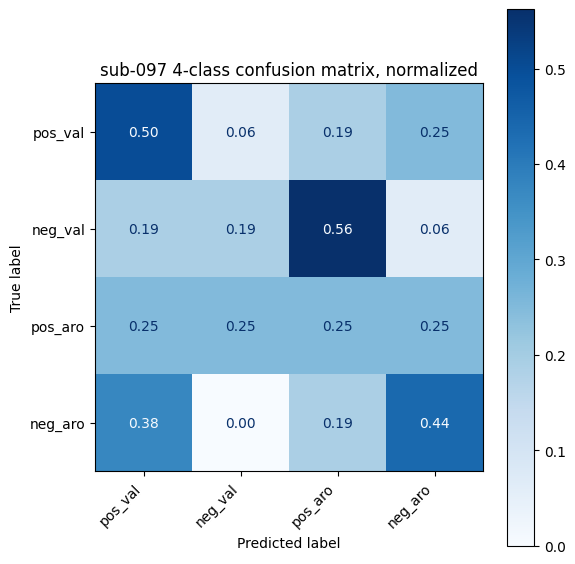

Saved normalized confusion matrix to: C:\ManzaRotation\Analysis\outputs\sub-097\decoding\fourclass_decoding\runs\001_2026-06-30_1128_fourclass_svc\figures\sub-097_4class_confusion_matrix_normalized.png
Confusion matrix:
[[8 1 3 4]
 [3 3 9 1]
 [4 4 4 4]
 [6 0 3 7]]

4-way accuracy: 0.344
Chance level: 0.250


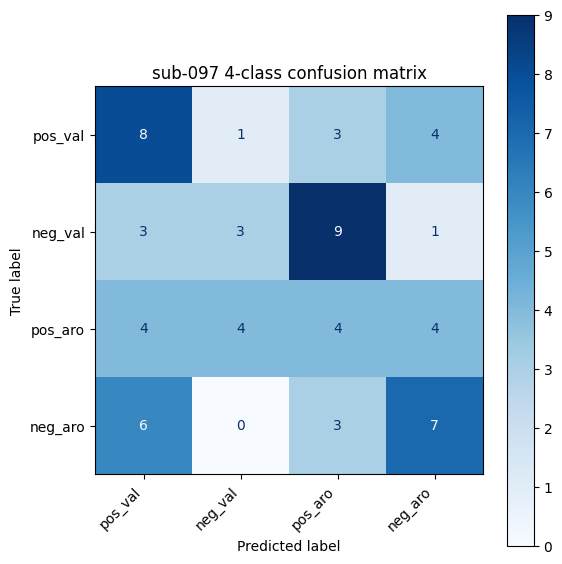

Saved figure to: C:\ManzaRotation\Analysis\outputs\sub-097\decoding\fourclass_decoding\runs\001_2026-06-30_1128_fourclass_svc\figures\sub-097_percentile=2_4class_confusion_matrix.png
Saved matrix to: C:\ManzaRotation\Analysis\outputs\sub-097\decoding\fourclass_decoding\runs\001_2026-06-30_1128_fourclass_svc\scores\sub-097_percentile=2_4class_confusion_matrix.csv


In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
import pandas as pd

# Explicit label order: valence classes together, arousal classes together
labels = ["pos_val", "neg_val", "pos_aro", "neg_aro"]

# Build confusion matrix
cm = confusion_matrix(y, y_pred, labels=labels)
cm_norm = confusion_matrix(
    y,
    y_pred,
    labels=labels,
    normalize="true",
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=labels,
)

fig, ax = plt.subplots(figsize=(6, 6))

disp.plot(
    cmap="Blues",
    colorbar=True,
    ax=ax,
    values_format=".2f",
)

ax.set_title(f"{subject} 4-class confusion matrix, normalized")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

norm_fig_path = figures_dir / f"{subject}_4class_confusion_matrix_normalized.png"
plt.savefig(norm_fig_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved normalized confusion matrix to: {norm_fig_path}")
print("Confusion matrix:")
print(cm)

# Overall 4-way accuracy
accuracy = accuracy_score(y, y_pred)
print(f"\n4-way accuracy: {accuracy:.3f}")
print("Chance level: 0.250")

# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels,
)

fig, ax = plt.subplots(figsize=(6, 6))

disp.plot(
    cmap="Blues",
    colorbar=True,
    ax=ax,
    values_format="d",
)

ax.set_title(f"{subject} 4-class confusion matrix")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

# Save figure
confusion_fig_path = figures_dir / f"{subject}_percentile={screening_percentile}_4class_confusion_matrix.png"
plt.savefig(confusion_fig_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {confusion_fig_path}")

# Optional: save the raw confusion matrix as a CSV too
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
cm_csv_path = results_dir / f"{subject}_percentile={screening_percentile}_4class_confusion_matrix.csv"
cm_df.to_csv(cm_csv_path)

print(f"Saved matrix to: {cm_csv_path}")

---
## Section 7 — Interpreting the Mistakes

Now read the matrix like a scientist, not just a scorekeeper. Ask:

- **Is the diagonal above chance?** With 16 trials per class, pure guessing puts
  ~4 on each diagonal cell. Noticeably more than 4 means that class is decodable.
- **Are confusions structured or random?** If `pos_val` is mostly confused with
  `neg_val` (and `pos_aro` with `neg_aro`), the decoder separates the *dimensions*
  but struggles with *sign within* a dimension — consistent with what notebooks
  01–03 hinted at. If confusions are spread evenly, there is no such structure.
- **Does any one class collapse?** A row that is almost entirely predicted as one
  other class can signal imbalance, a bad fold, or a class that simply isn't
  separable here.

**TODO:**
- [ ] In the markdown cell below, describe the diagonal vs off-diagonal pattern.
- [ ] State whether the confusions look like a "valence block vs arousal block"
      structure, and what that would imply.
- [ ] Connect it back to your binary results: is the multiclass story consistent
      with notebooks 01–03?

*Your reading of the confusion matrix:*

> (write here)

---
## Section 8 — Summary of the Whole Series

You have built a complete teaching decoding workflow for `sub-097`:

| notebook | question | classes | chance |
|---|---|---|---|
| 00 | (prepare the input tables) | — | — |
| 01 | positive vs negative **valence** | 2 | 50% |
| 02 | positive vs negative **arousal** | 2 | 50% |
| 03 | **valence** vs **arousal** dimension | 2 | 50% |
| 04 | all four conditions | 4 | 25% |

**The throughline:** the images never changed. Every different "result" came from
**how you labelled and grouped** the same 64 beta maps, and every honest result
depended on **leak-free cross-validation** that respected run boundaries.

**Where a real study goes next:**
- Repeat across **many subjects** and test the *group* accuracy against chance.
- Run a **permutation test** (shuffle `y` many times) to get an *empirical* chance
  distribution instead of assuming exactly 50% / 25%.
- Swap the whole-brain mask for **ROI masks** to localise *where* the information
  lives.
- Inspect **weight maps / confusion structure** to interpret representational
  geometry — carefully, with the Haufe-et-al. caveat in mind.

**TODO:**
- [ ] Write a few sentences summarising what you found across all four decoders
      for `sub-097`, and what you would do next if this were your own study.

*Your closing summary:*

> (write here)